# ECG Classification “ Eksperimen Skema Preprocessing

Notebook ini melatih model klasifikasi ECG dengan **3 skema preprocessing** dan **2 task klasifikasi**, sehingga total terdapat **6 kombinasi eksperimen**.

| Skema | Input | Task |
|---|---|---|
| Skema 1 | Gambar clean (1 gambar/sampel) | 2-class & 4-class |
| Skema 2 | 12 short lead + 1 long lead | 2-class & 4-class |
| Skema 3 | 6 lead tungkai + 6 lead precordial + long lead | 2-class & 4-class |

Semua eksperimen di-tracking menggunakan **MLflow via DagsHub**.

## 1. Import & Konfigurasi

In [33]:
import torch
from utils.config import Config
from utils.modeling import (
    init_dagshub,
    CLASS_NAMES_2, CLASS_NAMES_4,
    SCHEME_NAMES,
)

## GPU Check

In [34]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU tidak tersedia, menggunakan CPU")

GPU: NVIDIA GeForce RTX 5070 Ti
Memory: 17.1 GB


In [35]:
# ── Hyperparameter ──────────────────────────────────────────────
NUM_EPOCHS    = 5
BATCH_SIZE    = 16
LEARNING_RATE = 1e-4
IMAGE_SIZE    = 224
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
OUTPUT_DIR    = "outputs/experiments"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Inisialisasi DagsHub & MLflow

In [36]:
init_dagshub(
    repo_owner=Config.dagshub_config["repo_owner"],
    repo_name=Config.dagshub_config["repo_name"],
)

Initialized MLflow to track repo "abiyamf/TelUxMMU-Research"

Repository abiyamf/TelUxMMU-Research initialized!

DagsHub initialized: https://dagshub.com/abiyamf/TelUxMMU-Research


In [37]:
from utils.modeling import (
    _get_image_files_scheme1,
    ECGDatasetScheme1,
    build_dataloaders,
    build_model,
    train_model,
    evaluate_and_log,
)

records_s1 = _get_image_files_scheme1(Config.data_root)

dataset_s1_4c = ECGDatasetScheme1(records_s1, task="4class", image_size=IMAGE_SIZE)
train_s1_4c, val_s1_4c, test_s1_4c = build_dataloaders(
    dataset_s1_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_s1_4c, history_s1_4c, run_output_dir_s1_4c, run_id_s1_4c = train_model(
    model_s1_4c, train_s1_4c, val_s1_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_4class",
    scheme="scheme1", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme1_4class] Epoch 1/5 | Train Loss: 0.5062 Acc: 0.8056 | Val Loss: 0.4560 Acc: 0.8286
[scheme1_4class] Epoch 2/5 | Train Loss: 0.0881 Acc: 0.9815 | Val Loss: 0.0845 Acc: 0.9786
[scheme1_4class] Epoch 3/5 | Train Loss: 0.0240 Acc: 0.9969 | Val Loss: 0.0710 Acc: 0.9714
[scheme1_4class] Epoch 4/5 | Train Loss: 0.0201 Acc: 0.9985 | Val Loss: 0.0900 Acc: 0.9714


2026/04/19 19:00:02 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_4class] Epoch 5/5 | Train Loss: 0.0220 Acc: 0.9969 | Val Loss: 0.0537 Acc: 0.9714


2026/04/19 19:00:07 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 19:00:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_4class_20260419_185712\best_model.pth
Training history saved to: outputs/experiments\scheme1_4class_20260419_185712\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_4class_20260419_185712\confusion_matrix_val.png


In [38]:
result_s1_4c = evaluate_and_log(
    model_s1_4c, test_s1_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme1", task="4class",
    run_name="scheme1_4class",
    output_dir=run_output_dir_s1_4c,
    parent_run_id=run_id_s1_4c,
)


=== Test Results | scheme1 | 4class ===
Accuracy : 0.9643
Macro F1 : 0.9622
ROC-AUC  : 0.9963
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.97        43
    Abnormal       1.00      0.91      0.96        35
          MI       0.97      1.00      0.99        36
  History MI       0.96      0.92      0.94        26

    accuracy                           0.96       140
   macro avg       0.97      0.96      0.96       140
weighted avg       0.97      0.96      0.96       140

Test confusion matrix saved to: outputs/experiments\scheme1_4class_20260419_185712\confusion_matrix_test.png


In [39]:
dataset_s1_2c = ECGDatasetScheme1(records_s1, task="2class", image_size=IMAGE_SIZE)
train_s1_2c, val_s1_2c, test_s1_2c = build_dataloaders(
    dataset_s1_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_s1_2c, history_s1_2c, run_output_dir_s1_2c, run_id_s1_2c = train_model(
    model_s1_2c, train_s1_2c, val_s1_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_2class",
    scheme="scheme1", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme1_2class] Epoch 1/5 | Train Loss: 0.2476 Acc: 0.8889 | Val Loss: 0.1784 Acc: 0.9429
[scheme1_2class] Epoch 2/5 | Train Loss: 0.0705 Acc: 0.9769 | Val Loss: 0.1439 Acc: 0.9500
[scheme1_2class] Epoch 3/5 | Train Loss: 0.0614 Acc: 0.9753 | Val Loss: 0.0393 Acc: 0.9929
[scheme1_2class] Epoch 4/5 | Train Loss: 0.0560 Acc: 0.9892 | Val Loss: 0.0823 Acc: 0.9714


2026/04/19 19:04:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_2class] Epoch 5/5 | Train Loss: 0.0100 Acc: 0.9985 | Val Loss: 0.1374 Acc: 0.9643


2026/04/19 19:04:23 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 19:04:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_2class_20260419_190123\best_model.pth
Training history saved to: outputs/experiments\scheme1_2class_20260419_190123\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_2class_20260419_190123\confusion_matrix_val.png


In [40]:
result_s1_2c = evaluate_and_log(
    model_s1_2c, test_s1_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme1", task="2class",
    run_name="scheme1_2class",
    output_dir=run_output_dir_s1_2c,
    parent_run_id=run_id_s1_2c,
)


=== Test Results | scheme1 | 2class ===
Accuracy : 0.9929
Macro F1 : 0.9917
ROC-AUC  : 0.9995
              precision    recall  f1-score   support

       Sehat       0.98      1.00      0.99        43
       Sakit       1.00      0.99      0.99        97

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\scheme1_2class_20260419_190123\confusion_matrix_test.png


In [41]:
from utils.modeling import _get_image_files_scheme2, ECGDatasetScheme2

records_s2 = _get_image_files_scheme2(Config.data_root)

dataset_s2_4c = ECGDatasetScheme2(records_s2, task="4class", image_size=IMAGE_SIZE)
train_s2_4c, val_s2_4c, test_s2_4c = build_dataloaders(
    dataset_s2_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

# 13 leads x 3 channels = 39 input channels
model_s2_4c = build_model(num_classes=4, in_channels=39).to(DEVICE)

model_s2_4c, history_s2_4c, run_output_dir_s2_4c, run_id_s2_4c = train_model(
    model_s2_4c, train_s2_4c, val_s2_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_4class",
    scheme="scheme2", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme2_4class] Epoch 1/5 | Train Loss: 0.5846 Acc: 0.7778 | Val Loss: 0.8748 Acc: 0.6214
[scheme2_4class] Epoch 2/5 | Train Loss: 0.0817 Acc: 0.9861 | Val Loss: 0.9155 Acc: 0.6429
[scheme2_4class] Epoch 3/5 | Train Loss: 0.0529 Acc: 0.9907 | Val Loss: 0.4187 Acc: 0.8214
[scheme2_4class] Epoch 4/5 | Train Loss: 0.0307 Acc: 0.9923 | Val Loss: 0.8223 Acc: 0.6714


2026/04/19 19:09:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_4class] Epoch 5/5 | Train Loss: 0.0727 Acc: 0.9691 | Val Loss: 1.1839 Acc: 0.4714


2026/04/19 19:09:50 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 19:09:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_4class_20260419_190552\best_model.pth
Training history saved to: outputs/experiments\scheme2_4class_20260419_190552\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_4class_20260419_190552\confusion_matrix_val.png


In [42]:
result_s2_4c = evaluate_and_log(
    model_s2_4c, test_s2_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme2", task="4class",
    run_name="scheme2_4class",
    output_dir=run_output_dir_s2_4c,
    parent_run_id=run_id_s2_4c,
)


=== Test Results | scheme2 | 4class ===
Accuracy : 0.8500
Macro F1 : 0.8546
ROC-AUC  : 0.9908
              precision    recall  f1-score   support

      Normal       0.97      0.86      0.91        43
    Abnormal       0.64      0.97      0.77        35
          MI       1.00      0.75      0.86        36
  History MI       0.95      0.81      0.88        26

    accuracy                           0.85       140
   macro avg       0.89      0.85      0.85       140
weighted avg       0.89      0.85      0.86       140

Test confusion matrix saved to: outputs/experiments\scheme2_4class_20260419_190552\confusion_matrix_test.png


In [43]:
dataset_s2_2c = ECGDatasetScheme2(records_s2, task="2class", image_size=IMAGE_SIZE)
train_s2_2c, val_s2_2c, test_s2_2c = build_dataloaders(
    dataset_s2_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s2_2c = build_model(num_classes=2, in_channels=39).to(DEVICE)

model_s2_2c, history_s2_2c, run_output_dir_s2_2c, run_id_s2_2c = train_model(
    model_s2_2c, train_s2_2c, val_s2_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_2class",
    scheme="scheme2", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme2_2class] Epoch 1/5 | Train Loss: 0.3577 Acc: 0.8225 | Val Loss: 0.2193 Acc: 0.9357
[scheme2_2class] Epoch 2/5 | Train Loss: 0.1012 Acc: 0.9522 | Val Loss: 0.2428 Acc: 0.8857
[scheme2_2class] Epoch 3/5 | Train Loss: 0.0320 Acc: 0.9877 | Val Loss: 0.2810 Acc: 0.9000
[scheme2_2class] Epoch 4/5 | Train Loss: 0.0599 Acc: 0.9830 | Val Loss: 0.3104 Acc: 0.8571


2026/04/19 19:15:04 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_2class] Epoch 5/5 | Train Loss: 0.0359 Acc: 0.9877 | Val Loss: 0.0972 Acc: 0.9643


2026/04/19 19:15:08 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 19:15:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_2class_20260419_191123\best_model.pth
Training history saved to: outputs/experiments\scheme2_2class_20260419_191123\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_2class_20260419_191123\confusion_matrix_val.png


In [44]:
result_s2_2c = evaluate_and_log(
    model_s2_2c, test_s2_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme2", task="2class",
    run_name="scheme2_2class",
    output_dir=run_output_dir_s2_2c,
    parent_run_id=run_id_s2_2c,
)


=== Test Results | scheme2 | 2class ===
Accuracy : 0.9714
Macro F1 : 0.9660
ROC-AUC  : 0.9993
              precision    recall  f1-score   support

       Sehat       0.98      0.93      0.95        43
       Sakit       0.97      0.99      0.98        97

    accuracy                           0.97       140
   macro avg       0.97      0.96      0.97       140
weighted avg       0.97      0.97      0.97       140

Test confusion matrix saved to: outputs/experiments\scheme2_2class_20260419_191123\confusion_matrix_test.png


In [45]:
from utils.modeling import (
    _get_image_files_scheme3,
    ECGDatasetScheme3,
    build_model_multibranch,
    MultiBranchResNet18,
)

records_s3 = _get_image_files_scheme3(Config.data_root)

dataset_s3_4c = ECGDatasetScheme3(records_s3, task="4class", image_size=IMAGE_SIZE)
train_s3_4c, val_s3_4c, test_s3_4c = build_dataloaders(
    dataset_s3_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

# Multi-branch: limb (18ch) + precordial (18ch) + long lead (3ch)
model_s3_4c = build_model_multibranch(num_classes=4).to(DEVICE)

model_s3_4c, history_s3_4c, run_output_dir_s3_4c, run_id_s3_4c = train_model(
    model_s3_4c, train_s3_4c, val_s3_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_4class",
    scheme="scheme3", task="4class",
    model_name="ResNet-18 MultiBranch", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme3_4class] Epoch 1/5 | Train Loss: 0.4560 Acc: 0.8210 | Val Loss: 0.8686 Acc: 0.5714
[scheme3_4class] Epoch 2/5 | Train Loss: 0.0630 Acc: 0.9815 | Val Loss: 0.1487 Acc: 0.9786
[scheme3_4class] Epoch 3/5 | Train Loss: 0.0397 Acc: 0.9877 | Val Loss: 0.1623 Acc: 0.9500
[scheme3_4class] Epoch 4/5 | Train Loss: 0.0348 Acc: 0.9923 | Val Loss: 0.3201 Acc: 0.8857


2026/04/19 19:20:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_4class] Epoch 5/5 | Train Loss: 0.0135 Acc: 0.9969 | Val Loss: 0.1290 Acc: 0.9643


2026/04/19 19:20:34 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 19:20:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_4class_20260419_191643\best_model.pth
Training history saved to: outputs/experiments\scheme3_4class_20260419_191643\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_4class_20260419_191643\confusion_matrix_val.png


In [46]:
result_s3_4c = evaluate_and_log(
    model_s3_4c, test_s3_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme3", task="4class",
    run_name="scheme3_4class",
    output_dir=run_output_dir_s3_4c,
    parent_run_id=run_id_s3_4c,
)


=== Test Results | scheme3 | 4class ===
Accuracy : 0.9500
Macro F1 : 0.9452
ROC-AUC  : 0.9946
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.98        43
    Abnormal       0.85      0.97      0.91        35
          MI       1.00      1.00      1.00        36
  History MI       0.96      0.85      0.90        26

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.95       140
weighted avg       0.95      0.95      0.95       140

Test confusion matrix saved to: outputs/experiments\scheme3_4class_20260419_191643\confusion_matrix_test.png


In [47]:
dataset_s3_2c = ECGDatasetScheme3(records_s3, task="2class", image_size=IMAGE_SIZE)
train_s3_2c, val_s3_2c, test_s3_2c = build_dataloaders(
    dataset_s3_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_2c = build_model_multibranch(num_classes=2).to(DEVICE)

model_s3_2c, history_s3_2c, run_output_dir_s3_2c, run_id_s3_2c = train_model(
    model_s3_2c, train_s3_2c, val_s3_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_2class",
    scheme="scheme3", task="2class",
    model_name="ResNet-18 MultiBranch", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme3_2class] Epoch 1/5 | Train Loss: 0.2142 Acc: 0.9151 | Val Loss: 0.1986 Acc: 0.9071
[scheme3_2class] Epoch 2/5 | Train Loss: 0.0337 Acc: 0.9892 | Val Loss: 0.4727 Acc: 0.7786
[scheme3_2class] Epoch 3/5 | Train Loss: 0.0547 Acc: 0.9846 | Val Loss: 0.0846 Acc: 0.9714
[scheme3_2class] Epoch 4/5 | Train Loss: 0.0222 Acc: 0.9923 | Val Loss: 0.0989 Acc: 0.9786


2026/04/19 19:26:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_2class] Epoch 5/5 | Train Loss: 0.0177 Acc: 0.9938 | Val Loss: 0.3901 Acc: 0.8500


2026/04/19 19:26:33 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 19:26:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_2class_20260419_192242\best_model.pth
Training history saved to: outputs/experiments\scheme3_2class_20260419_192242\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_2class_20260419_192242\confusion_matrix_val.png


## 4. Raw Data (Tanpa Preprocessing)

Section ini melatih model ResNet-18 menggunakan data mentah (raw) dari folder `data/raw/` tanpa preprocessing apapun.

In [ ]:
from utils.modeling import _get_image_files_raw, ECGDatasetRaw

records_raw = _get_image_files_raw(Config.data_root)

dataset_raw_4c = ECGDatasetRaw(records_raw, task="4class", image_size=IMAGE_SIZE)
train_raw_4c, val_raw_4c, test_raw_4c = build_dataloaders(
    dataset_raw_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_raw_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_raw_4c, history_raw_4c, run_output_dir_raw_4c, run_id_raw_4c = train_model(
    model_raw_4c, train_raw_4c, val_raw_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="raw_4class",
    scheme="raw", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

In [ ]:
result_raw_4c = evaluate_and_log(
    model_raw_4c, test_raw_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="raw", task="4class",
    run_name="raw_4class",
    output_dir=run_output_dir_raw_4c,
    parent_run_id=run_id_raw_4c,
)

In [ ]:
dataset_raw_2c = ECGDatasetRaw(records_raw, task="2class", image_size=IMAGE_SIZE)
train_raw_2c, val_raw_2c, test_raw_2c = build_dataloaders(
    dataset_raw_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_raw_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_raw_2c, history_raw_2c, run_output_dir_raw_2c, run_id_raw_2c = train_model(
    model_raw_2c, train_raw_2c, val_raw_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="raw_2class",
    scheme="raw", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

In [ ]:
result_raw_2c = evaluate_and_log(
    model_raw_2c, test_raw_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="raw", task="2class",
    run_name="raw_2class",
    output_dir=run_output_dir_raw_2c,
    parent_run_id=run_id_raw_2c,
)

## 5. Long Lead Only (Lead II – Preprocessed)

Section ini melatih model ResNet-18 menggunakan hanya long lead (13_long_lead.png) dari data yang sudah melalui preprocessing.

In [ ]:
from utils.modeling import _get_image_files_longlead, ECGDatasetLongLead

records_ll = _get_image_files_longlead(Config.data_root)

dataset_ll_4c = ECGDatasetLongLead(records_ll, task="4class", image_size=IMAGE_SIZE)
train_ll_4c, val_ll_4c, test_ll_4c = build_dataloaders(
    dataset_ll_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_ll_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_ll_4c, history_ll_4c, run_output_dir_ll_4c, run_id_ll_4c = train_model(
    model_ll_4c, train_ll_4c, val_ll_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="longlead_4class",
    scheme="longlead", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

In [ ]:
result_ll_4c = evaluate_and_log(
    model_ll_4c, test_ll_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="longlead", task="4class",
    run_name="longlead_4class",
    output_dir=run_output_dir_ll_4c,
    parent_run_id=run_id_ll_4c,
)

In [ ]:
dataset_ll_2c = ECGDatasetLongLead(records_ll, task="2class", image_size=IMAGE_SIZE)
train_ll_2c, val_ll_2c, test_ll_2c = build_dataloaders(
    dataset_ll_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_ll_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_ll_2c, history_ll_2c, run_output_dir_ll_2c, run_id_ll_2c = train_model(
    model_ll_2c, train_ll_2c, val_ll_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="longlead_2class",
    scheme="longlead", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

In [ ]:
result_ll_2c = evaluate_and_log(
    model_ll_2c, test_ll_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="longlead", task="2class",
    run_name="longlead_2class",
    output_dir=run_output_dir_ll_2c,
    parent_run_id=run_id_ll_2c,
)

In [48]:
result_s3_2c = evaluate_and_log(
    model_s3_2c, test_s3_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme3", task="2class",
    run_name="scheme3_2class",
    output_dir=run_output_dir_s3_2c,
    parent_run_id=run_id_s3_2c,
)


=== Test Results | scheme3 | 2class ===
Accuracy : 0.9786
Macro F1 : 0.9753
ROC-AUC  : 0.9981
              precision    recall  f1-score   support

       Sehat       0.93      1.00      0.97        43
       Sakit       1.00      0.97      0.98        97

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140

Test confusion matrix saved to: outputs/experiments\scheme3_2class_20260419_192242\confusion_matrix_test.png


=== Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch) ===
                 Scheme    Task  Accuracy  Macro F1  ROC-AUC
       Scheme 2 (Stack) 4-Class    0.8500    0.8546   0.9908
       Scheme 2 (Stack) 2-Class    0.9714    0.9660   0.9993
Scheme 3 (Multi-Branch) 4-Class    0.9500    0.9452   0.9946
Scheme 3 (Multi-Branch) 2-Class    0.9786    0.9753   0.9981


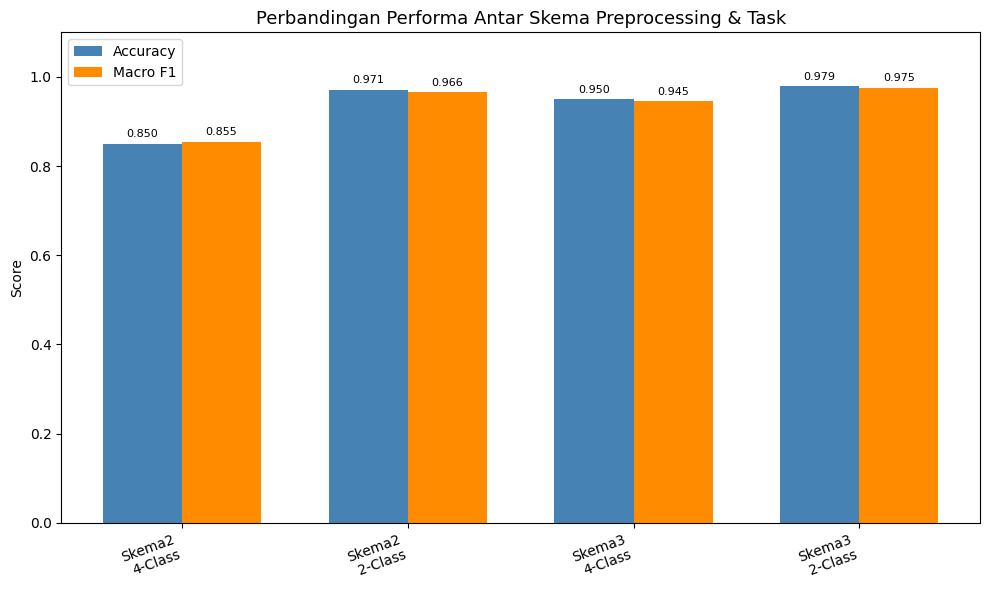

In [49]:
# Perbandingan Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch)
import pandas as pd

comparison_data = {
    "Scheme":   ["Scheme 2 (Stack)", "Scheme 2 (Stack)",
                 "Scheme 3 (Multi-Branch)", "Scheme 3 (Multi-Branch)"],
    "Task":     ["4-Class", "2-Class", "4-Class", "2-Class"],
    "Accuracy": [result_s2_4c["accuracy"], result_s2_2c["accuracy"],
                 result_s3_4c["accuracy"], result_s3_2c["accuracy"]],
    "Macro F1": [result_s2_4c["f1"],       result_s2_2c["f1"],
                 result_s3_4c["f1"],        result_s3_2c["f1"]],
    "ROC-AUC":  [result_s2_4c["roc_auc"],  result_s2_2c["roc_auc"],
                 result_s3_4c["roc_auc"],   result_s3_2c["roc_auc"]],
}

df_compare = pd.DataFrame(comparison_data)
print("=== Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch) ===")
print(df_compare.to_string(index=False, float_format="{:.4f}".format))

from utils.modeling import plot_scheme_comparison
plot_scheme_comparison({
    "Skema2\n4-Class": result_s2_4c,
    "Skema2\n2-Class": result_s2_2c,
    "Skema3\n4-Class": result_s3_4c,
    "Skema3\n2-Class": result_s3_2c,
})

## 6. Visualisasi Perbandingan Hasil

Bagian ini membandingkan performa semua skema dan task secara visual.

### 6.1 Training History – Task 4-Class

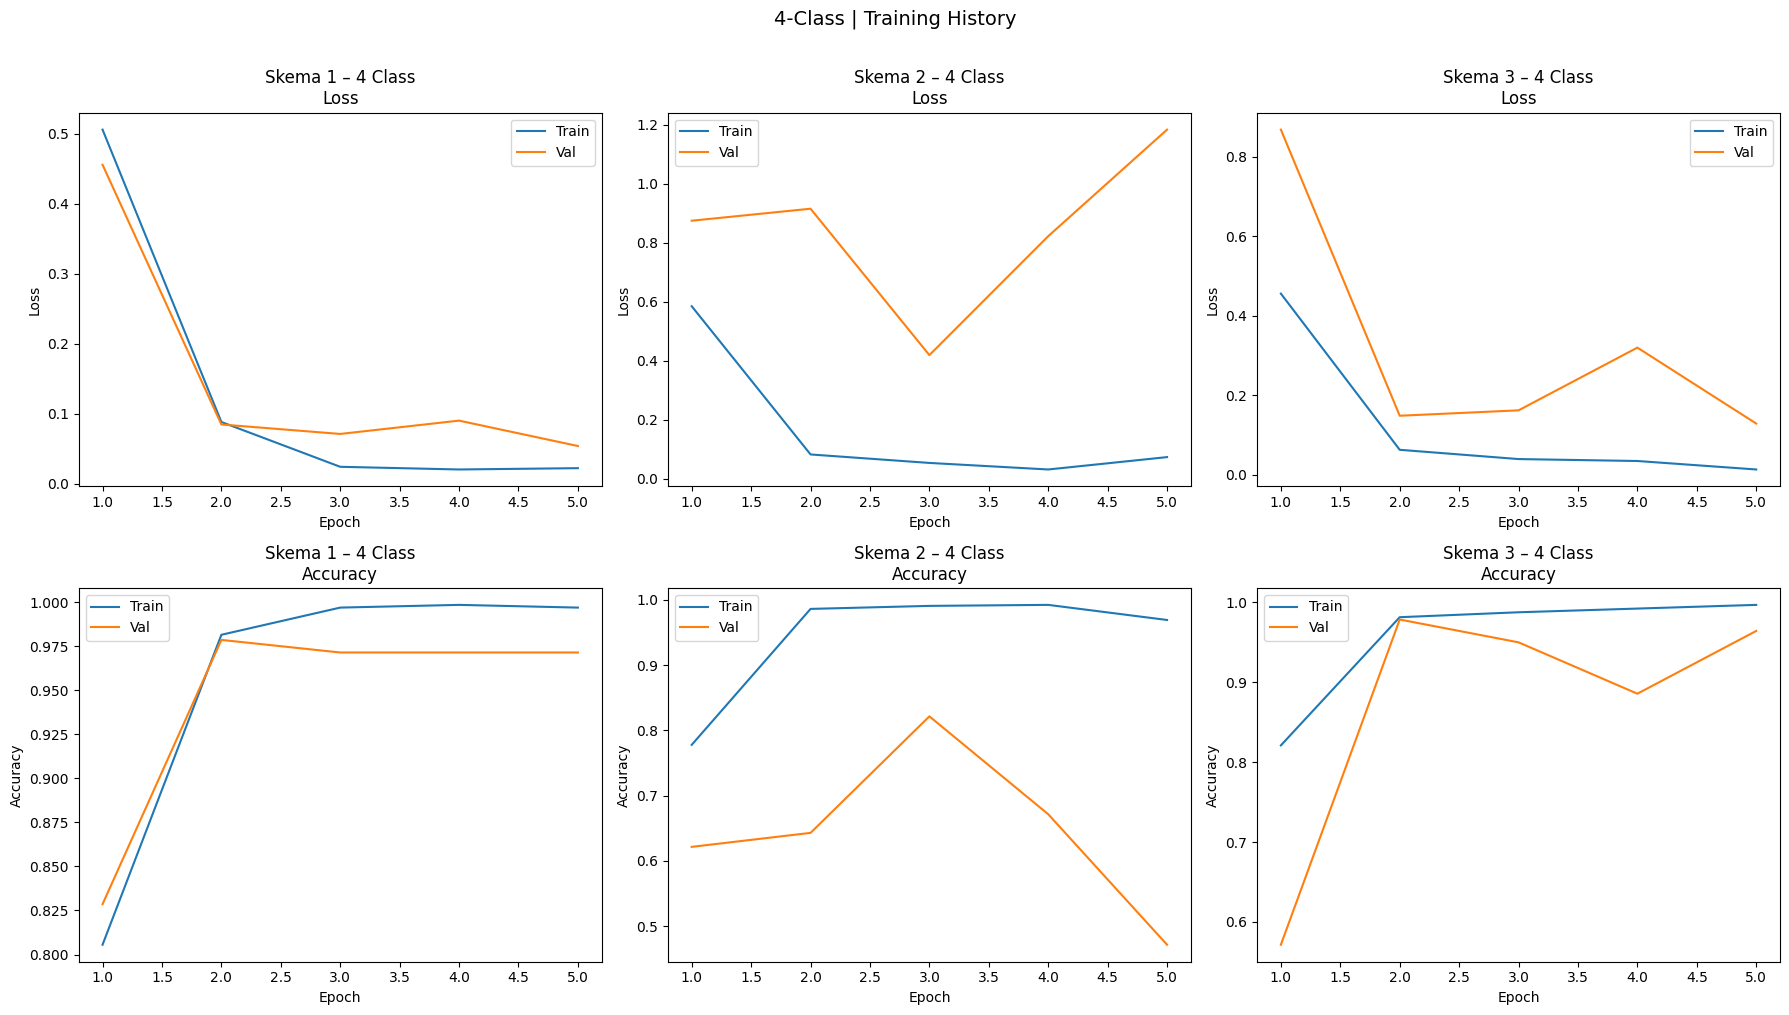

In [50]:
from utils.modeling import plot_training_history

plot_training_history(
    histories={
        "Skema 1 – 4 Class": history_s1_4c,
        "Skema 2 – 4 Class": history_s2_4c,
        "Skema 3 – 4 Class": history_s3_4c,
        "Raw – 4 Class": history_raw_4c,
        "Long Lead – 4 Class": history_ll_4c,
    },
    title_prefix="4-Class | "
)

### 6.2 Training History – Task 2-Class

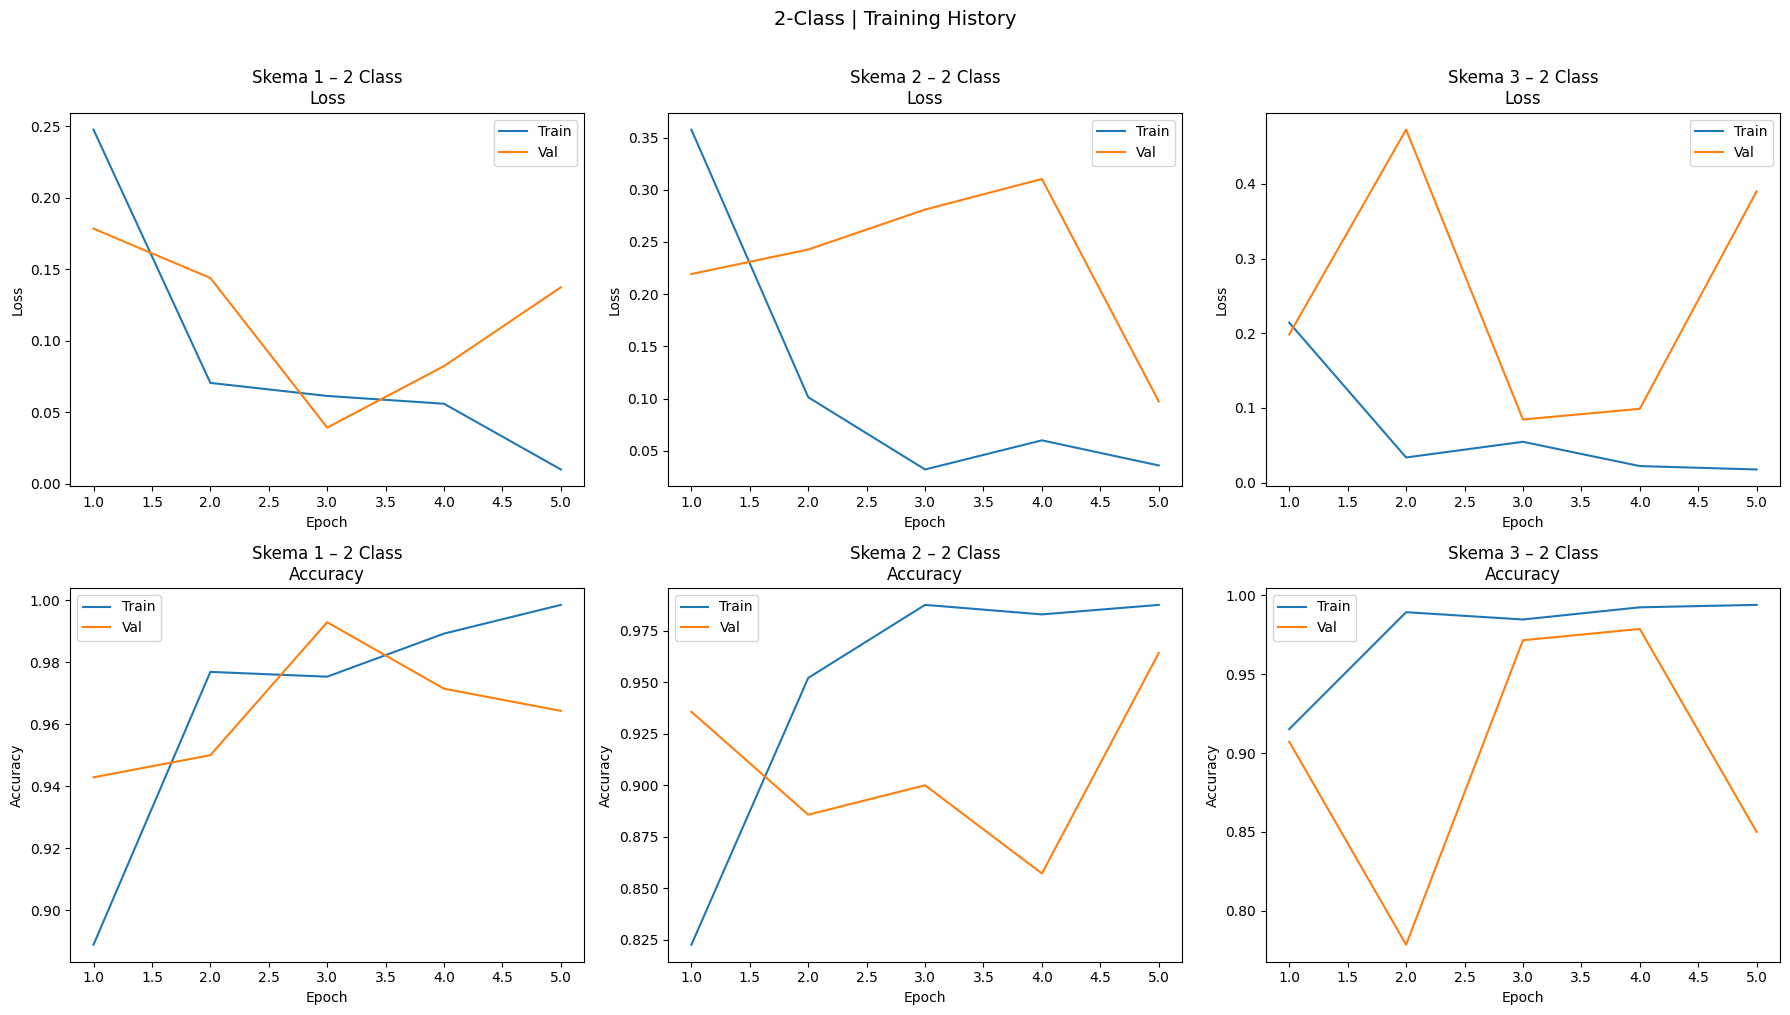

In [51]:
plot_training_history(
    histories={
        "Skema 1 – 2 Class": history_s1_2c,
        "Skema 2 – 2 Class": history_s2_2c,
        "Skema 3 – 2 Class": history_s3_2c,
        "Raw – 2 Class": history_raw_2c,
        "Long Lead – 2 Class": history_ll_2c,
    },
    title_prefix="2-Class | "
)

### 6.3 Confusion Matrix – Task 4-Class

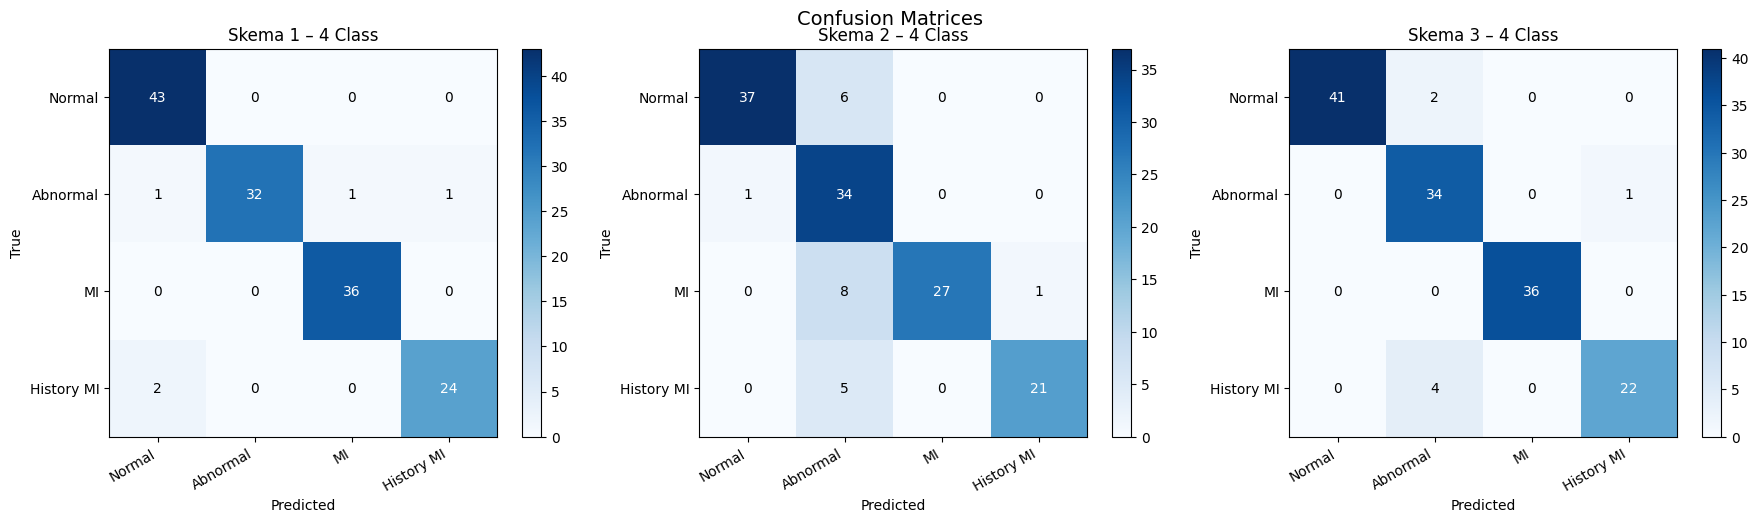

In [52]:
from utils.modeling import plot_confusion_matrices

plot_confusion_matrices(
    results={
        "Skema 1 – 4 Class": result_s1_4c,
        "Skema 2 – 4 Class": result_s2_4c,
        "Skema 3 – 4 Class": result_s3_4c,
        "Raw – 4 Class": result_raw_4c,
        "Long Lead – 4 Class": result_ll_4c,
    },
    class_names=CLASS_NAMES_4
)

### 6.4 Confusion Matrix – Task 2-Class

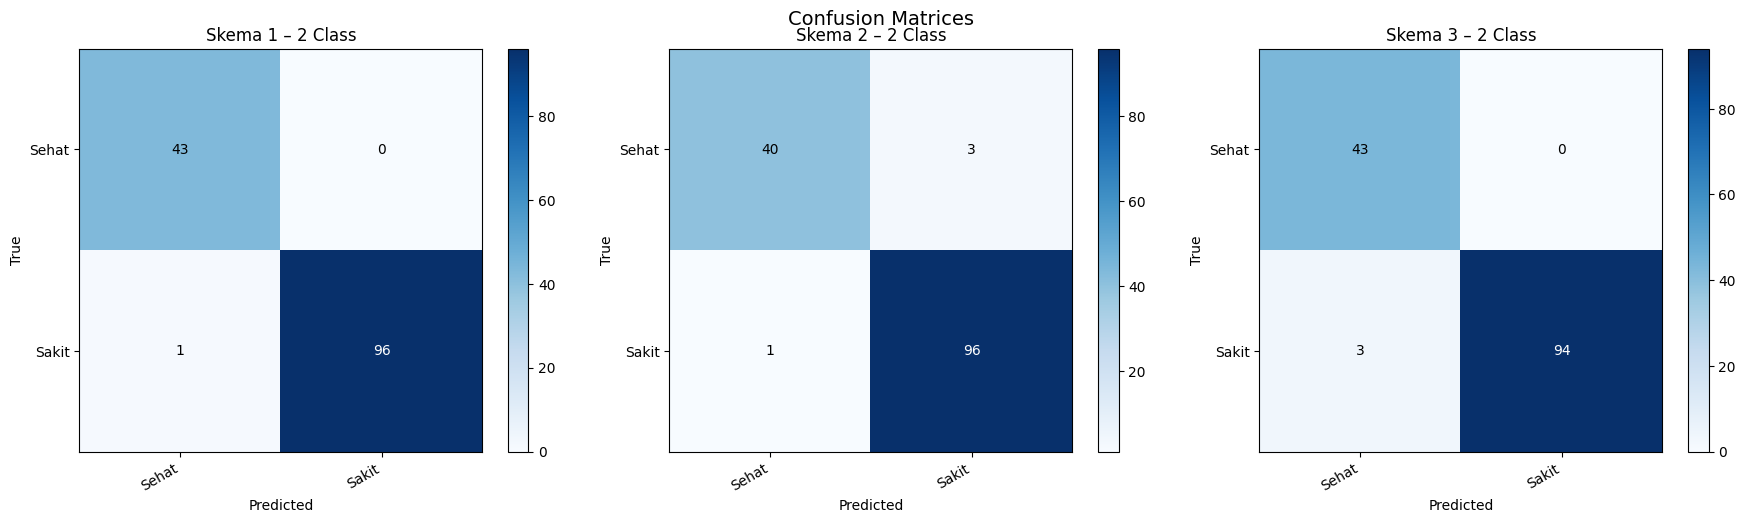

In [53]:
plot_confusion_matrices(
    results={
        "Skema 1 – 2 Class": result_s1_2c,
        "Skema 2 – 2 Class": result_s2_2c,
        "Skema 3 – 2 Class": result_s3_2c,
        "Raw – 2 Class": result_raw_2c,
        "Long Lead – 2 Class": result_ll_2c,
    },
    class_names=CLASS_NAMES_2
)

### 6.5 Perbandingan Akhir – Accuracy & Macro F1 Semua Skema

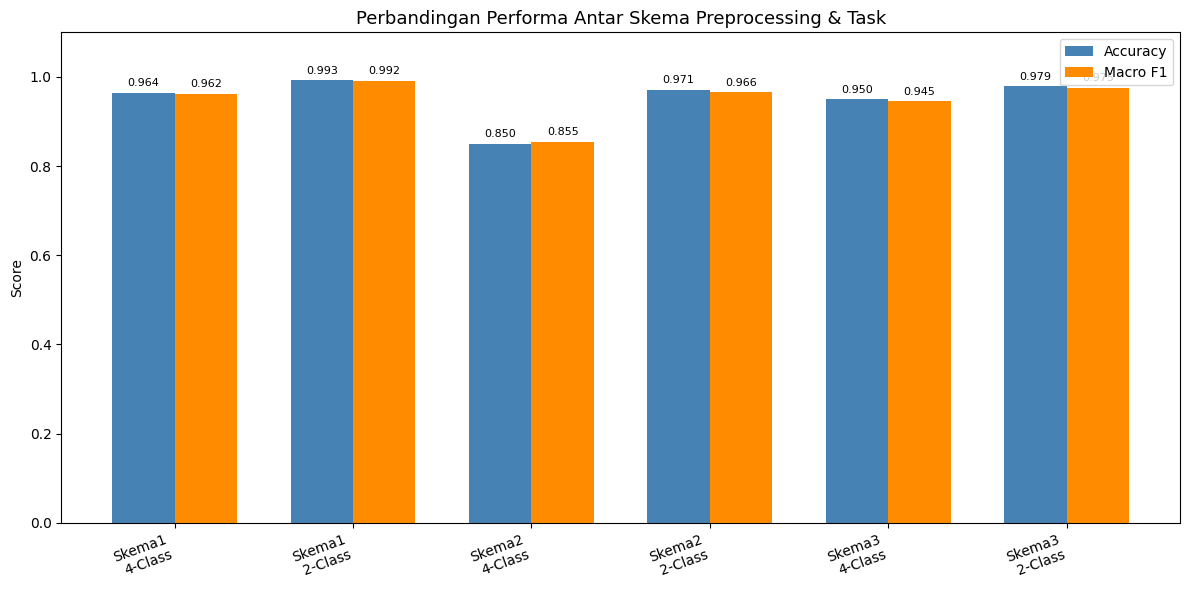

In [54]:
from utils.modeling import plot_scheme_comparison

all_results = {
    "Skema1\n4-Class": result_s1_4c,
    "Skema1\n2-Class": result_s1_2c,
    "Skema2\n4-Class": result_s2_4c,
    "Skema2\n2-Class": result_s2_2c,
    "Skema3\n4-Class": result_s3_4c,
    "Skema3\n2-Class": result_s3_2c,
    "Raw\n4-Class": result_raw_4c,
    "Raw\n2-Class": result_raw_2c,
    "LongLead\n4-Class": result_ll_4c,
    "LongLead\n2-Class": result_ll_2c,
}

plot_scheme_comparison(all_results)

### 6.6 Sample Predictions – Skema Terbaik

Visualisasi prediksi model pada sampel acak dari dataset test. Ganti variabel `best_model` dan `best_dataset` sesuai skema dengan performa terbaik dari grafik di atas.

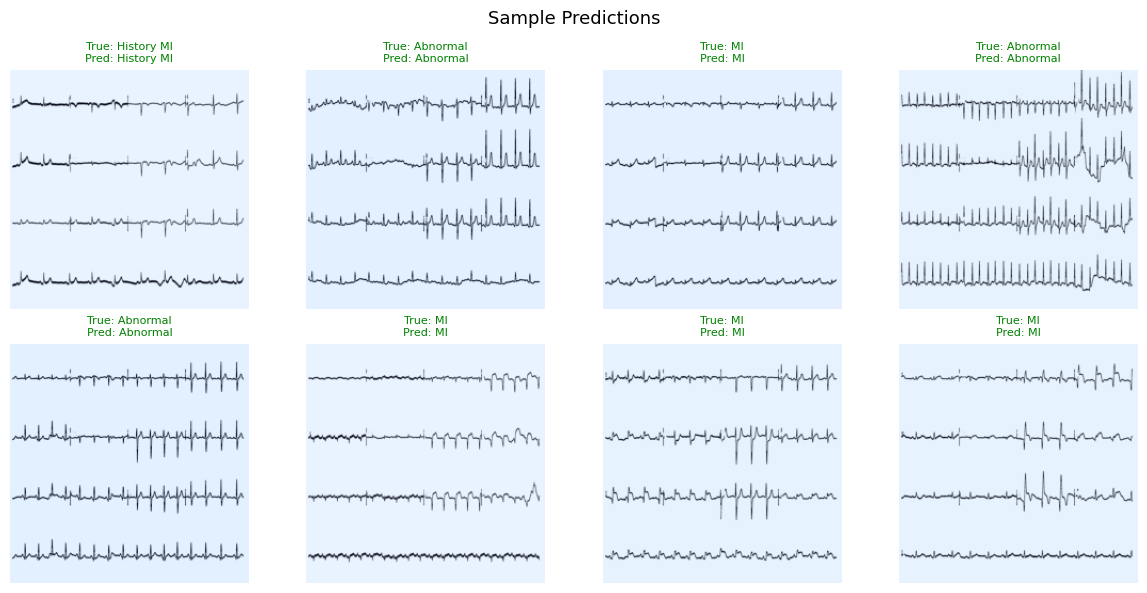

In [ ]:
from utils.modeling import plot_sample_predictions

# Ganti model dan dataset sesuai hasil terbaik yang diperoleh
best_model   = model_s1_4c
best_dataset = dataset_s1_4c
best_classes = CLASS_NAMES_4

plot_sample_predictions(
    model=best_model,
    dataset=best_dataset,
    class_names=best_classes,
    device=DEVICE,
    num_samples=8
)